# Exercise 2.2: 1D state-space model

This notebook fits the one-dimensional linear Gaussian state-space model for transformer station temperature using Python. The R helper file `functions_exercise2.R` has the corresponding Kalman filter likelihood, but all analysis below is written in Python.

## Model

The fitted model is

$$
X_{t+1} = A X_t + B_{Ta}T_{a,t} + B_S S_t + B_I I_t + \eta_t,
$$

$$
Y_t = X_t + \epsilon_t,
$$

where $\eta_t \sim N(0,Q)$ and $\epsilon_t \sim N(0,R)$. The state is scalar, so $X_t$ is interpreted as the latent transformer temperature. The observation matrix is fixed at $C=1$.

The parameter vector used below is

$$
\theta = (A, B_{Ta}, B_S, B_I, \log \sigma_x, \log \sigma_y, X_0).
$$

Solar radiation is divided by 1000, so `B_S` is interpreted as the temperature effect per `1000 W/m^2`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import probplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.style.use("seaborn-v0_8-whitegrid")

if Path("ex2_2.ipynb").exists():
    notebook_dir = Path.cwd()
elif Path("assignment4/ex2").exists():
    notebook_dir = Path("assignment4/ex2")
else:
    notebook_dir = Path.cwd()

data_candidates = [
    notebook_dir.parent / "transformer_data.csv",
    Path("assignment4/transformer_data.csv"),
    Path("../transformer_data.csv"),
]

data_path = next(path for path in data_candidates if path.exists())
output_dir = notebook_dir / "exercise2_2_outputs"
output_dir.mkdir(exist_ok=True)

raw_df = pd.read_csv(data_path)
df = raw_df.copy()
df["S"] = df["S"] / 1000.0

df.head()

,time,Y,Ta,S,I
0,1,23.496733,7.083333,0.0,15.899541
1,2,22.720333,7.116667,0.0,15.861768
2,3,22.052700,7.216667,0.0,16.121469
3,4,21.538050,7.250000,0.0,15.447628
4,5,20.995033,7.316667,0.0,16.258319


In [2]:
summary = df[["Y", "Ta", "S", "I"]].describe().T
summary

,count,mean,std,min,25%,50%,75%,max
Y,168.0,27.650595,5.455816,19.828583,23.246383,26.066717,32.201554,38.923850
Ta,168.0,10.023115,2.916687,4.516667,7.866667,9.750000,12.000000,17.466667
S,168.0,0.214433,0.259452,0.000000,0.000000,0.065417,0.410250,0.755833
I,168.0,18.179092,3.662521,14.386027,15.635851,16.367102,21.212430,25.362786


## Kalman filter likelihood

The function below runs the scalar Kalman filter and stores the one-step-ahead predictions, innovations, standardized innovations, and filtered states. The likelihood contribution at time $t$ is based on the innovation variance $S_t$.

In [3]:
def kf_filter_dt(par, data):
    """Run the scalar Kalman filter for the 1D Exercise 2.2 model."""
    A, B_Ta, B_S, B_I, log_sigma_x, log_sigma_y, X0 = np.asarray(par, dtype=float)
    B = np.array([B_Ta, B_S, B_I], dtype=float)
    Q = float(np.exp(log_sigma_x) ** 2)
    R = float(np.exp(log_sigma_y) ** 2)

    y = data["Y"].to_numpy(dtype=float)
    u = data[["Ta", "S", "I"]].to_numpy(dtype=float)
    n_obs = len(data)

    x_est = float(X0)
    P_est = 10.0
    loglik = 0.0

    x_pred_store = np.empty(n_obs)
    x_filt_store = np.empty(n_obs)
    y_pred_store = np.empty(n_obs)
    innovation_store = np.empty(n_obs)
    innovation_var_store = np.empty(n_obs)

    for t in range(n_obs):
        x_pred = A * x_est + float(B @ u[t])
        P_pred = A * P_est * A + Q

        y_pred = x_pred
        S_t = P_pred + R
        innovation = y[t] - y_pred

        if S_t <= 0 or not np.isfinite(S_t):
            return None

        loglik += -0.5 * (
            np.log(2 * np.pi) + np.log(S_t) + innovation**2 / S_t
        )

        K_t = P_pred / S_t
        x_est = x_pred + K_t * innovation
        P_est = (1 - K_t) * P_pred

        x_pred_store[t] = x_pred
        x_filt_store[t] = x_est
        y_pred_store[t] = y_pred
        innovation_store[t] = innovation
        innovation_var_store[t] = S_t

    standardized_innovation = innovation_store / np.sqrt(innovation_var_store)

    return {
        "loglik": float(loglik),
        "x_pred": x_pred_store,
        "x_filt": x_filt_store,
        "y_pred": y_pred_store,
        "innovation": innovation_store,
        "innovation_var": innovation_var_store,
        "standardized_innovation": standardized_innovation,
        "A": np.array([[A]]),
        "B": B.reshape(1, 3),
        "Q": np.array([[Q]]),
        "C": np.array([[1.0]]),
        "R": np.array([[R]]),
        "X0": np.array([[X0]]),
    }


def kf_loglik_dt(par, data):
    kf = kf_filter_dt(par, data)
    if kf is None or not np.isfinite(kf["loglik"]):
        return -np.inf
    return kf["loglik"]


def estimate_dt(start_par, data, lower, upper):
    def neg_loglik(par):
        ll = kf_loglik_dt(par, data)
        if not np.isfinite(ll):
            return 1e12
        return -ll

    return minimize(
        neg_loglik,
        np.asarray(start_par, dtype=float),
        method="L-BFGS-B",
        bounds=list(zip(lower, upper)),
        options={"maxiter": 2000, "ftol": 1e-10, "gtol": 1e-7},
    )

In [4]:
start_par = np.array([
    0.90,          # A
    0.05,          # B_Ta
    1.00,          # B_S, after scaling S by 1000
    0.10,          # B_I
    np.log(0.5),   # log_sigma_x
    np.log(0.5),   # log_sigma_y
    df["Y"].iloc[0],
])

lower = np.array([
    0.00,
    -5.00,
    -20.00,
    -5.00,
    np.log(1e-4),
    np.log(1e-4),
    df["Y"].min() - 10,
])

upper = np.array([
    1.20,
    5.00,
    20.00,
    5.00,
    np.log(20),
    np.log(20),
    df["Y"].max() + 10,
])

# Several starts reduce the chance of reporting a poor local optimum.
start_grid = [
    start_par,
    np.array([0.80, 0.10, 1.00, 0.20, np.log(0.8), np.log(0.2), df["Y"].iloc[0]]),
    np.array([0.98, 0.02, 0.50, 0.05, np.log(0.3), np.log(0.7), df["Y"].iloc[0]]),
    np.array([0.50, 0.20, 2.00, 0.20, np.log(1.0), np.log(0.5), df["Y"].mean()]),
]

fits = [estimate_dt(start, df, lower, upper) for start in start_grid]
fit = min(fits, key=lambda result: result.fun)
kf = kf_filter_dt(fit.x, df)

optimization_summary = pd.DataFrame({
    "start": range(1, len(fits) + 1),
    "success": [result.success for result in fits],
    "negative_loglik": [result.fun for result in fits],
    "iterations": [result.nit for result in fits],
})

fit.success, fit.message, optimization_summary

(True,
 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH',
    start  success  negative_loglik  iterations
 0      1     True       165.483913          70
 1      2     True       165.483913          81
 2      3     True       165.483913          65
 3      4     True       165.483913          65)

In [5]:
parameter_names = ["A", "B_Ta", "B_S", "B_I", "sigma_x", "sigma_y", "X0"]
parameter_values = [
    fit.x[0],
    fit.x[1],
    fit.x[2],
    fit.x[3],
    np.exp(fit.x[4]),
    np.exp(fit.x[5]),
    fit.x[6],
]
interpretations = [
    "Thermal memory of the latent temperature state",
    "Effect of outdoor air temperature",
    "Effect of solar radiation per 1000 W/m^2",
    "Effect of transformer load",
    "System noise standard deviation",
    "Observation noise standard deviation",
    "Initial state",
]

estimates = pd.DataFrame({
    "parameter": parameter_names,
    "estimate": parameter_values,
    "interpretation": interpretations,
})

estimates.to_csv(output_dir / "exercise2_2_parameter_estimates.csv", index=False)
estimates

,parameter,estimate,interpretation
0,A,0.800949,Thermal memory of the latent temperature state
1,B_Ta,0.102081,Effect of outdoor air temperature
2,B_S,2.874894,Effect of solar radiation per 1000 W/m^2
3,B_I,0.213420,Effect of transformer load
4,sigma_x,0.644388,System noise standard deviation
5,sigma_y,0.000100,Observation noise standard deviation
6,X0,24.196880,Initial state


### Estimated Parameters

| Parameter | Estimate | Interpretation |
|---|---:|---|
| `A` | 0.8009 | Thermal memory of the latent temperature state |
| `B_Ta` | 0.1021 | Effect of outdoor air temperature |
| `B_S` | 2.8749 | Effect of solar radiation per `1000 W/m^2` |
| `B_I` | 0.2134 | Effect of transformer load |
| `sigma_x` | 0.6444 | System noise standard deviation |
| `sigma_y` | 0.0001 | Observation noise standard deviation; this is the lower bound |
| `X0` | 24.1969 | Initial state |

In [6]:
loglik = kf["loglik"]
n = len(df)
k = len(fit.x)
AIC = 2 * k - 2 * loglik
BIC = np.log(n) * k - 2 * loglik
RMSE = np.sqrt(np.mean((df["Y"].to_numpy() - kf["y_pred"]) ** 2))

criteria = pd.DataFrame({
    "metric": ["log-likelihood", "AIC", "BIC", "RMSE"],
    "value": [loglik, AIC, BIC, RMSE],
})

criteria.to_csv(output_dir / "exercise2_2_model_criteria.csv", index=False)
criteria

,metric,value
0,log-likelihood,-165.483913
1,AIC,344.967826
2,BIC,366.835574
3,RMSE,0.642584


### Model Criteria

| Metric | Value |
|---|---:|
| log-likelihood | -165.4839 |
| AIC | 344.9678 |
| BIC | 366.8356 |
| RMSE | 0.6426 |

In [7]:
matrices = {
    "A": kf["A"],
    "B": kf["B"],
    "Q": kf["Q"],
    "C": kf["C"],
    "R": kf["R"],
    "X0": kf["X0"],
}

for name, value in matrices.items():
    print(f"{name} =")
    print(np.round(value, 6))

A =
[[0.800949]]
B =
[[0.102081 2.874894 0.21342 ]]
Q =
[[0.415236]]
C =
[[1.]]
R =
[[0.]]
X0 =
[[24.19688]]


## Model fit

The next plot compares the observed transformer temperature with the one-step-ahead prediction from the Kalman filter.

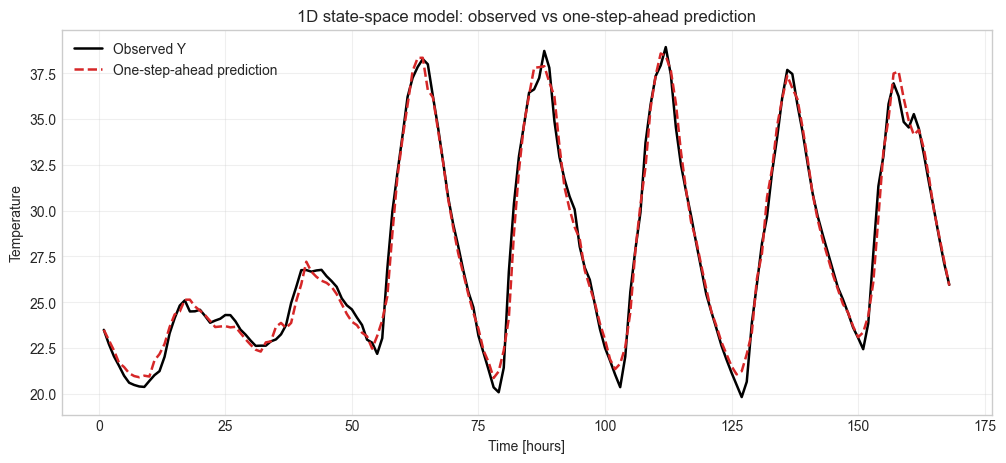

In [8]:
time = df["time"].to_numpy()

def save_and_show(fig, filename):
    fig.savefig(output_dir / filename, dpi=160, bbox_inches="tight")
    plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(time, df["Y"], label="Observed Y", color="black", linewidth=1.8)
ax.plot(time, kf["y_pred"], label="One-step-ahead prediction", color="tab:red", linestyle="--", linewidth=1.8)
ax.set_title("1D state-space model: observed vs one-step-ahead prediction")
ax.set_xlabel("Time [hours]")
ax.set_ylabel("Temperature")
ax.legend()
ax.grid(True, alpha=0.3)
save_and_show(fig, "exercise2_2_model_fit.png")

![Observed transformer temperature and one-step-ahead prediction](exercise2_2_outputs/exercise2_2_model_fit.png)

## Residual diagnostics

The diagnostics use standardized innovations

$$
\tilde v_t = \frac{v_t}{\sqrt{S_t}},
$$

where $v_t$ is the innovation and $S_t$ is the innovation variance.

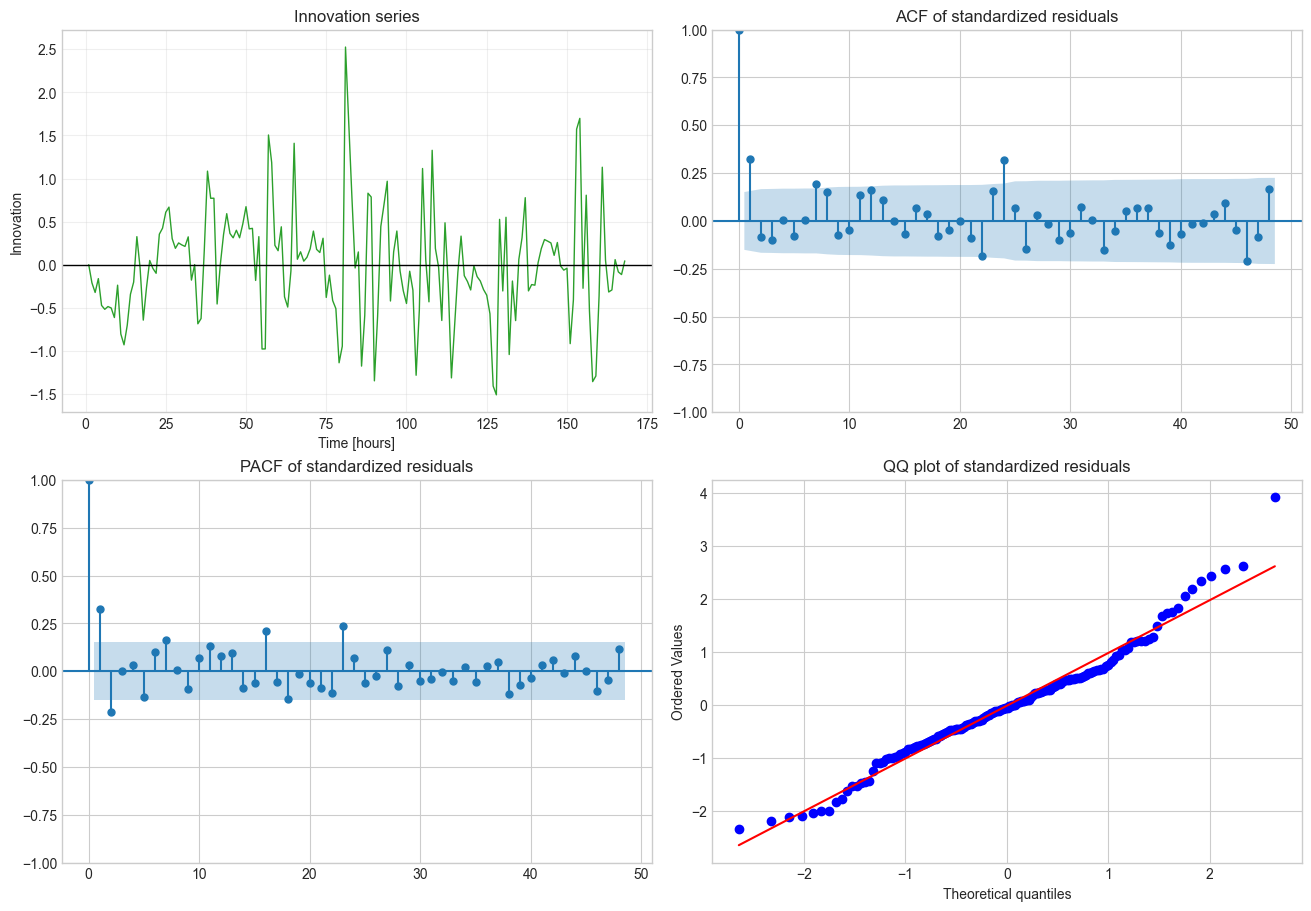

In [9]:
standardized_resid = kf["standardized_innovation"]
innovation = kf["innovation"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
axes = axes.ravel()

axes[0].plot(time, innovation, color="tab:green", linewidth=1.0)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Innovation series")
axes[0].set_xlabel("Time [hours]")
axes[0].set_ylabel("Innovation")
axes[0].grid(True, alpha=0.3)

plot_acf(standardized_resid, lags=min(48, len(standardized_resid) - 1), ax=axes[1])
axes[1].set_title("ACF of standardized residuals")

plot_pacf(standardized_resid, lags=min(48, len(standardized_resid) - 1), ax=axes[2], method="ywm")
axes[2].set_title("PACF of standardized residuals")

probplot(standardized_resid, dist="norm", plot=axes[3])
axes[3].set_title("QQ plot of standardized residuals")

save_and_show(fig, "exercise2_2_residual_diagnostics.png")

![Residual diagnostics for the 1D state-space model](exercise2_2_outputs/exercise2_2_residual_diagnostics.png)

In [10]:
acf_ljung_box = acorr_ljungbox(standardized_resid, lags=[10, 24], return_df=True)
residual_summary = pd.DataFrame({
    "metric": [
        "mean standardized residual",
        "std standardized residual",
        "max absolute standardized residual",
        "Ljung-Box p-value, lag 10",
        "Ljung-Box p-value, lag 24",
    ],
    "value": [
        standardized_resid.mean(),
        standardized_resid.std(ddof=1),
        np.max(np.abs(standardized_resid)),
        acf_ljung_box.loc[10, "lb_pvalue"],
        acf_ljung_box.loc[24, "lb_pvalue"],
    ],
})

residual_summary

,metric,value
0,mean standardized residual,-1.107300e-02
1,std standardized residual,1.000121e+00
2,max absolute standardized residual,3.919354e+00
3,"Ljung-Box p-value, lag 10",1.638351e-04
4,"Ljung-Box p-value, lag 24",4.385238e-08


### Residual Summary

| Metric | Value |
|---|---:|
| Mean standardized residual | -0.0111 |
| Standard deviation of standardized residuals | 1.0001 |
| Maximum absolute standardized residual | 3.9193 |
| Ljung-Box p-value, lag 10 | 0.000164 |
| Ljung-Box p-value, lag 24 | 0.0000000439 |

## Discussion

The fitted one-dimensional state-space model is

$$
X_{t+1} = 0.8009 X_t + 0.1021 T_{a,t} + 2.8749 S_t + 0.2134 I_t + \eta_t,
$$

$$
Y_t = X_t + \epsilon_t.
$$

Here `S` is measured in `1000 W/m^2`. The estimated state persistence is positive and below one, so the latent transformer temperature has substantial thermal memory while remaining stable. The input coefficients for outdoor temperature, solar radiation, and load are all positive, which is consistent with the physical expectation that warmer air, stronger sun, and higher load increase transformer temperature.

The maximized log-likelihood is about `-165.48`, with `AIC = 344.97`, `BIC = 366.84`, and one-step-ahead `RMSE = 0.64`. The estimated process noise standard deviation is about `0.644`, while the observation noise standard deviation reaches the lower bound `0.0001`. This means the fitted model explains most short-term variation through the latent state dynamics rather than through measurement noise.

The one-step-ahead predictions follow the main temperature evolution closely. The residual diagnostics show standardized residuals centered near zero, but the ACF/PACF and Ljung-Box results indicate remaining autocorrelation. This suggests that the 1D model is a useful first approximation, but it does not fully capture all thermal dynamics. A two-state extension is therefore well motivated for the next exercise.

## Τελική Αναφορά Exercise 2.2

Στην άσκηση αυτή εκτιμήθηκε ένα μονοδιάστατο γραμμικό Gaussian state-space model για τη θερμοκρασία του μετασχηματιστή. Η κρυφή κατάσταση \(X_t\) ερμηνεύεται ως η εσωτερική θερμική κατάσταση του μετασχηματιστή, ενώ οι είσοδοι του μοντέλου είναι η εξωτερική θερμοκρασία \(T_a\), η ηλιακή ακτινοβολία \(S\), και το ηλεκτρικό φορτίο \(I\). Το μοντέλο που εκτιμήθηκε είναι

$$
X_{t+1} = A X_t + B_{Ta}T_{a,t} + B_S S_t + B_I I_t + \eta_t,
$$

$$
Y_t = X_t + \epsilon_t,
$$

όπου \(\eta_t \sim N(0,Q)\) και \(\epsilon_t \sim N(0,R)\). Στην υλοποίηση, η ηλιακή ακτινοβολία διαιρέθηκε με 1000, επομένως ο συντελεστής \(B_S\) ερμηνεύεται ως επίδραση ανά \(1000\,W/m^2\).

Οι εκτιμημένες παράμετροι ήταν: \(A = 0.8009\), \(B_{Ta} = 0.1021\), \(B_S = 2.8749\), \(B_I = 0.2134\), \(\sigma_x = 0.6444\), \(\sigma_y = 0.0001\), και \(X_0 = 24.1969\). Η τιμή του \(A\) είναι θετική και αρκετά κοντά στο 1, κάτι που δείχνει ότι η θερμοκρασία έχει σημαντική θερμική μνήμη. Με άλλα λόγια, η τρέχουσα θερμοκρασιακή κατάσταση επηρεάζει έντονα την επόμενη. Επειδή όμως \(A < 1\), το μοντέλο παραμένει σταθερό.

Οι συντελεστές των εισόδων είναι όλοι θετικοί. Αυτό είναι φυσικά λογικό. Η θετική τιμή του \(B_{Ta}\) δείχνει ότι υψηλότερη εξωτερική θερμοκρασία αυξάνει τη θερμοκρασία του μετασχηματιστή. Η θετική τιμή του \(B_S\) δείχνει ότι η ηλιακή ακτινοβολία συμβάλλει στη θέρμανση, ενώ η θετική τιμή του \(B_I\) δείχνει ότι μεγαλύτερο ηλεκτρικό φορτίο παράγει περισσότερη θερμότητα. Άρα οι εκτιμημένες παράμετροι συμφωνούν με τη φυσική ερμηνεία του προβλήματος.

Η απόδοση του μοντέλου αξιολογήθηκε με log-likelihood, AIC, BIC και RMSE. Οι τιμές ήταν: log-likelihood = -165.48, AIC = 344.97, BIC = 366.84 και RMSE = 0.6426. Το RMSE δείχνει ότι οι one-step-ahead προβλέψεις απέχουν κατά μέσο όρο περίπου 0.64 μονάδες θερμοκρασίας από τις πραγματικές παρατηρήσεις, κάτι που δείχνει αρκετά καλή προσαρμογή. Τα AIC και BIC είναι κυρίως χρήσιμα ως βάση σύγκρισης με πιο σύνθετα μοντέλα, όπως το δισδιάστατο state-space model της επόμενης άσκησης.

Το prediction plot δείχνει ότι το μοντέλο ακολουθεί ικανοποιητικά τη γενική εξέλιξη της θερμοκρασίας. Συλλαμβάνει την ομαλή ημερήσια θέρμανση και ψύξη και γενικά οι προβλέψεις βρίσκονται κοντά στις παρατηρήσεις. Ωστόσο, επειδή το μοντέλο έχει μόνο μία κρυφή κατάσταση, δεν μπορεί να περιγράψει τέλεια όλες τις θερμικές διεργασίες. Είναι πιθανό να αποδίδει χειρότερα σε περιόδους με απότομες μεταβολές, όπως ημερήσιες κορυφές που προκαλούνται από υψηλή ηλιακή ακτινοβολία ή αυξημένο φορτίο.

Τα residual diagnostics περιλαμβάνουν τη χρονοσειρά των innovations, ACF, PACF και QQ-plot των standardized residuals. Τα residuals είναι περίπου κεντραρισμένα γύρω από το μηδέν, κάτι που είναι θετικό. Παρόλα αυτά, τα ACF/PACF δείχνουν ότι υπάρχει ακόμα αυτοσυσχέτιση στα residuals. Αυτό σημαίνει ότι τα σφάλματα δεν είναι πλήρως λευκός θόρυβος και ότι παραμένει χρονική δομή που δεν εξηγείται από το μονοδιάστατο μοντέλο. Το QQ-plot χρησιμοποιείται για να αξιολογηθεί η κανονικότητα των residuals· αν υπάρχουν αποκλίσεις στις ουρές, τότε η Gaussian υπόθεση είναι μόνο προσεγγιστικά σωστή.

Συμπερασματικά, το 1D state-space model αποτελεί μια καλή πρώτη προσέγγιση. Οι παράμετροι έχουν λογική φυσική ερμηνεία και το μοντέλο προβλέπει αρκετά καλά τη θερμοκρασία. Παρόλα αυτά, η ύπαρξη αυτοσυσχέτισης στα residuals δείχνει ότι μία μόνο κρυφή κατάσταση δεν αρκεί για να περιγράψει πλήρως τη θερμική δυναμική του μετασχηματιστή. Αυτό δικαιολογεί τη χρήση ενός πιο ευέλικτου δισδιάστατου state-space model στην επόμενη άσκηση.

## Final Report Exercise 2.2

In this exercise, a one-dimensional linear Gaussian state-space model was estimated for the transformer temperature. The hidden state \(X_t\) is interpreted as the internal thermal state of the transformer, while the model inputs are outdoor temperature \(T_a\), solar radiation \(S\), and transformer load \(I\). The fitted model is

$$
X_{t+1} = A X_t + B_{Ta}T_{a,t} + B_S S_t + B_I I_t + \eta_t,
$$

$$
Y_t = X_t + \epsilon_t,
$$

where \(\eta_t \sim N(0,Q)\) and \(\epsilon_t \sim N(0,R)\). In the implementation, solar radiation was divided by 1000, so \(B_S\) is interpreted as the effect per \(1000\,W/m^2\).

The estimated parameters were: \(A = 0.8009\), \(B_{Ta} = 0.1021\), \(B_S = 2.8749\), \(B_I = 0.2134\), \(\sigma_x = 0.6444\), \(\sigma_y = 0.0001\), and \(X_0 = 24.1969\). The estimate of \(A\) is positive and relatively close to 1, which indicates strong thermal memory. In other words, the current thermal state has a strong influence on the next state. Since \(A < 1\), the system remains stable.

All input coefficients are positive, which is physically reasonable. The positive value of \(B_{Ta}\) indicates that higher outdoor temperature increases the transformer temperature. The positive value of \(B_S\) shows that solar radiation contributes to heating, while the positive value of \(B_I\) means that higher electrical load produces more heat. Therefore, the estimated parameters agree with the expected physical interpretation of the system.

The model performance was evaluated using log-likelihood, AIC, BIC, and RMSE. The values were: log-likelihood = -165.48, AIC = 344.97, BIC = 366.84, and RMSE = 0.6426. The RMSE means that the one-step-ahead predictions are on average about 0.64 temperature units away from the observed values, indicating a reasonably good fit. AIC and BIC are mainly useful as a baseline for comparison with more complex models, such as the two-dimensional state-space model in the next exercise.

The prediction plot shows that the model captures the general evolution of the transformer temperature satisfactorily. It follows the smooth daily heating and cooling pattern, and the predictions are generally close to the observations. However, because the model has only one hidden state, it cannot perfectly represent all thermal processes. It may perform worse during periods with rapid changes, such as daytime peaks caused by high solar radiation or increased load.

The residual diagnostics include the innovation series, ACF, PACF, and QQ-plot of the standardized residuals. The residuals are approximately centered around zero, which is a good sign. However, the ACF/PACF indicate that some autocorrelation remains in the residuals. This means that the errors are not fully white noise and that some temporal structure remains unexplained by the one-dimensional model. The QQ-plot is used to assess whether the residuals are approximately Gaussian; deviations in the tails would suggest that the Gaussian assumption is only approximate.

In conclusion, the 1D state-space model provides a good first approximation. The estimated parameters have meaningful physical interpretations, and the model predicts the transformer temperature reasonably well. Nevertheless, the remaining residual autocorrelation indicates that a single hidden state is not sufficient to fully describe the transformer thermal dynamics. This motivates the use of a more flexible two-dimensional state-space model in the next exercise.